<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/fargopy-tutorial-control_fargo3d.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: control FARGO3D from Python

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p ./gallery/


Not running in Colab, skipping installation


### What's in this notebook

In this notebook we illustrate in depth **how to control `FARGO3D` (setup, compile and run)** in `FARGOpy`.

### Before starting

If you are in `Google Colab`, install the latest version of the package:

For this tutorial you will need the following external modules and tools:

In [1]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd


Running FARGOpy version 0.4.0


### Let's `FARGOpy`

We call *control* the possibility to setup and run `FARGO3D` from an `IPython/Jupyter` session.

You should start by initializing fargopy, namely getting FARGO3D:

In [2]:
fp.initialize('download', force=True)

Cloning into 'fargo3d'...


	FARGO3D downloaded to /Users/jzuluaga/fargo3d/
Header file for FARGO3D found in the fargo directory /Users/jzuluaga/fargo3d/


First we need to create an empty `Simulation` object:

In [3]:
sim = fp.Simulation()

Your simulation is now connected with '/Users/jzuluaga/fargo3d/'


You can verify that the simulation is clean by printing the object:

In [4]:
print(sim)

Simulation information:
    FARGO3D directory: /Users/jzuluaga/fargo3d/
        Outputs: /Users/jzuluaga/fargo3d/outputs
        Setups: /Users/jzuluaga/fargo3d/setups
    Units:
        G = 1 UL^3/(UM UT^2)
        UL, UM, UT = 14959800000000.0 m, 1.9891e+33 kg, 5022421.439871778 s
        UE = 5271139.687948494 J/m^3
        UV = 2978603.086001067 m/s
        URHO = 5.941269533317109e-07 kg/m^3
        USIGMA = 8888020.39645173 kg/m^2
    Setup: None
    Setup directory: None
    Output directory: None



Next thing to do is to select the `setup` you want to control. You can obtain a list of setups using:

In [5]:
fp.Simulation.list_setups()

Setup 'binary' in '/Users/jzuluaga/fargo3d/setups/binary'
Setup 'fargo' in '/Users/jzuluaga/fargo3d/setups/fargo'
Setup 'fargo_multifluid' in '/Users/jzuluaga/fargo3d/setups/fargo_multifluid'
Setup 'fargo_nu' in '/Users/jzuluaga/fargo3d/setups/fargo_nu'
Setup 'mri' in '/Users/jzuluaga/fargo3d/setups/mri'
Setup 'otvortex' in '/Users/jzuluaga/fargo3d/setups/otvortex'
Setup 'p3diso' in '/Users/jzuluaga/fargo3d/setups/p3diso'
Setup 'p3disof' in '/Users/jzuluaga/fargo3d/setups/p3disof'
Setup 'sod1d' in '/Users/jzuluaga/fargo3d/setups/sod1d'



Choose a setup:

In [6]:
sim.set_setup('fargo')

Now your simulation setup is at '/Users/jzuluaga/fargo3d/setups/fargo'


'fargo'

Compile the `FARGO3D` binary to run the simulation:

In [7]:
sim.compile(parallel=0,gpu=0)

Compiling fargo3d-SETUP_fargo-PARALLEL_0-GPU_0...
Succesful compilation of FARGO3D binary fargo3d-SETUP_fargo-PARALLEL_0-GPU_0


Run the simulation:

In [8]:
sim.run(cleanrun=True,unlock=True)

No output directory /Users/jzuluaga/fargo3d/outputs/fargo yet created.
Running asynchronously (test = False):  ./fargo3d-SETUP_fargo-PARALLEL_0-GPU_0 -m -t setups/fargo/fargo.par
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/fargo'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.4917968750000004)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 1
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Or check the progress of the simulation:

In [9]:
sim.status('progress')


################################################################################

Progress of the simulation (interrupt by pressing the stop button):
1:OUTPUTS 2 at date t = 12.566371 OK [output pace = 0.1 secs]
2:OUTPUTS 3 at date t = 18.849556 OK [output pace = 0.1 secs]
3:OUTPUTS 4 at date t = 25.132741 OK [output pace = 0.6 secs]
4:OUTPUTS 5 at date t = 31.415927 OK [output pace = 1.0 secs]
Interrupted by user.

Other status modes: 'isrunning', 'logfile', 'outputs', 'progress', 'summary'


You may stop the simulation at any time using:

In [10]:
sim.stop()

The process is locked by PID 72556
The process has finished. Check logfile /Users/jzuluaga/fargo3d/setups/fargo/fargo.log.


Check the status of the simulation using:

In [11]:
sim.status('isrunning summary progress')


################################################################################
Running status of the process:
	The process has ended with termination code 0.

################################################################################
Summary:
The simulation has been ran for 6 time-steps (including the initial one).

################################################################################

Progress of the simulation (interrupt by pressing the stop button):
The simulation is not running anymore

Other status modes: 'isrunning', 'logfile', 'outputs', 'progress', 'summary'


Once stopped you may resume the simulation at any snapshot or at the latest resumable snapshot:

In [12]:
sim.resume()

Resuming from snapshot 4...
Running asynchronously (test = False):  ./fargo3d-SETUP_fargo-PARALLEL_0-GPU_0 -m -t -S 4 -t setups/fargo/fargo.par
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/fargo'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.4917968750000004)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 6
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Once the simulation has been completed you will notice by ran:

In [15]:
sim.stop()

The process is locked by PID 72683
The process has finished. Check logfile /Users/jzuluaga/fargo3d/setups/fargo/fargo.log.


In [17]:
sim = fp.Simulation()

Your simulation is now connected with '/Users/jzuluaga/fargo3d/'


In [18]:
sim.list_setups()

Setup 'binary' in '/Users/jzuluaga/fargo3d/setups/binary'
Setup 'fargo' in '/Users/jzuluaga/fargo3d/setups/fargo'
Setup 'fargo_multifluid' in '/Users/jzuluaga/fargo3d/setups/fargo_multifluid'
Setup 'fargo_nu' in '/Users/jzuluaga/fargo3d/setups/fargo_nu'
Setup 'mri' in '/Users/jzuluaga/fargo3d/setups/mri'
Setup 'otvortex' in '/Users/jzuluaga/fargo3d/setups/otvortex'
Setup 'p3diso' in '/Users/jzuluaga/fargo3d/setups/p3diso'
Setup 'p3disof' in '/Users/jzuluaga/fargo3d/setups/p3disof'
Setup 'sod1d' in '/Users/jzuluaga/fargo3d/setups/sod1d'



In [19]:
sim = fp.Simulation(setup='fargo',load=True)

Loading simulation from '/Users/jzuluaga/fargo3d/setups/fargo/fargopy_simulation.json'
Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now your simulation setup is at '/Users/jzuluaga/fargo3d/setups/fargo'
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/fargo'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.4917968750000004)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 51
Planets found in summary.dat:
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


Now we can plot the result:

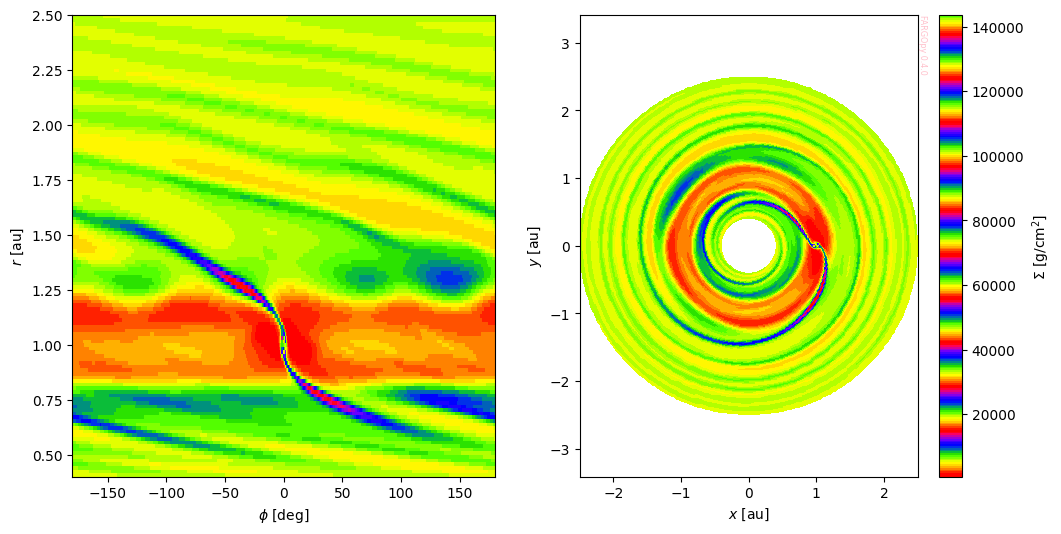

In [21]:
gasdens_all = sim.load_allfields('gasdens')
gasdens_snap = gasdens_all[20].gasdens
gasdens_plane,mesh = gasdens_snap.meshslice(slice='z=0')

fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'prism'

ax = axs[0]
ax.pcolormesh(mesh.phi*fp.RAD,mesh.r*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$\phi$ [deg]')
ax.set_ylabel('$r$ [au]')

ax = axs[1]
c = ax.pcolormesh(mesh.x*sim.UL/fp.AU,mesh.y*sim.UL/fp.AU,gasdens_plane*sim.USIGMA,cmap=cmap)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')
ax.axis('equal')
fp.Plot.fargopy_mark(ax)

axc = fig.colorbar(c)
axc.set_label("$\Sigma$ [g/cm$^2$]")
plt.savefig('gallery/fargopy-tutorial-control_0.png') # Save figure


---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
